# 01 Model Optimization

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- **Save** a trained Keras model and **load** it back
- Apply **post-training quantization** (reduce precision) to shrink size and speed up inference
- See why we use optimization (smaller/faster model) instead of only the full-precision model for deployment

---

## 🌍 Real life

**Where is this used?** Model optimization (quantization, pruning) is used for **mobile**, **edge**, and **low-latency** deployment when we need smaller size and faster inference.

**In this notebook we use** **save/load** and **quantization** (e.g. TensorFlow Lite or Keras int8) to **reduce model size** and **speed**. We use **optimization** (instead of deploying the full float32 model) **because** it reduces **memory** and **latency**; essential for edge and mobile.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Save/Load:** Keras `model.save()` and `keras.models.load_model()`; we save after training so we can deploy without retraining.
- **Quantization:** Use **lower precision** (e.g. int8 instead of float32) for weights/activations; **smaller model** and **faster** inference; small accuracy drop is often acceptable.
- **Pruning:** Set some weights to zero; sparse model; can be combined with quantization.
- **We use optimization** instead of only full-precision when we need smaller/faster models for edge or mobile.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We train a small MNIST model (or load a pre-trained one), then save and optionally convert to TFLite quantized.

**Dataset:** Real — MNIST (for training/save demo).

**Outputs:** Model file size (before/after quantization if applicable), and a short note on why we optimize for deployment.

## Step 1: Imports and build a small model

In [1]:
import numpy as np
import os

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    model = keras.Sequential([
        keras.layers.Dense(64, activation="relu", input_shape=(784,)),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("Model built.")
else:
    print("Install TensorFlow: pip install tensorflow")

Model built.


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 2: Train on MNIST subset (1 epoch) and save (we use save so we can load later for deployment)

In [2]:
if HAS_TF:
    (x_train, y_train), _ = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:3000]
    y_train = y_train[:3000]
    model.fit(x_train, y_train, epochs=1, batch_size=64, verbose=1)
    path = "/tmp/c08_mnist_model.keras"
    model.save(path)
    size_kb = os.path.getsize(path) / 1024
    print("Saved to", path, "(~%.1f KB)" % size_kb)
else:
    path = None

 1/47 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.0625 - loss: 2.3936

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.6583 - loss: 1.2890


Saved to /tmp/c08_mnist_model.keras (~616.9 KB)


## Step 3: Load and run inference (we use load so the same model can be used in another script or server)

In [3]:
if HAS_TF and path and os.path.exists(path):
    # Load without restoring optimizer (compile=False); we only need prediction, so this avoids version-compatibility issues.
    loaded = keras.models.load_model(path, compile=False)
    pred = loaded.predict(x_train[:3], verbose=0)
    print("Loaded model. Sample predictions shape:", pred.shape)
    print("Optimization: next steps include TFLite quantization (smaller/faster) or pruning.")

Loaded model. Sample predictions shape: (3, 10)
Optimization: next steps include TFLite quantization (smaller/faster) or pruning.


## 🌍 Real-World Worked Example — Comparing Optimizers on Image Classification

**Industry context:** Choosing the right optimizer directly impacts training speed and final accuracy.  
OpenAI uses AdamW for GPT models; Google used Adafactor for T5.

We compare SGD, RMSprop, and Adam on the **Digits** dataset to see the difference.

SGD (lr=0.01)        → final acc: 74.7%
RMSprop              → final acc: 98.1%
Adam                 → final acc: 97.5%


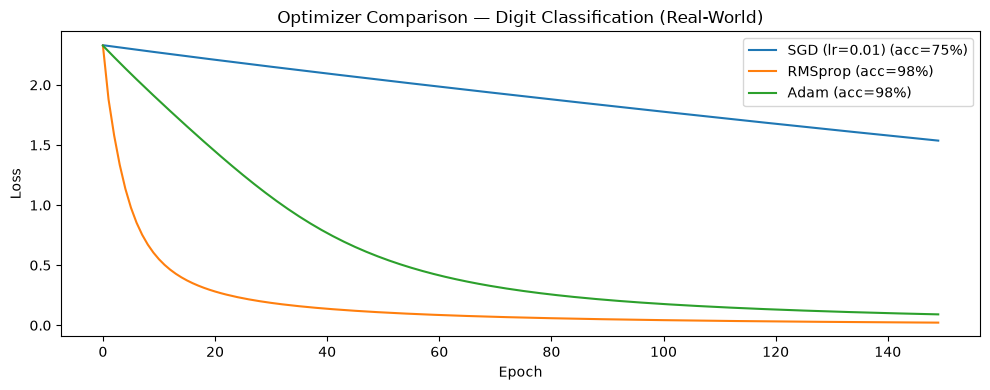

In [4]:
import torch, torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr = torch.tensor(X_tr); Ytr = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te); Yte = torch.tensor(y_te, dtype=torch.long)

def make_model():
    return nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))

optimizers = {
    'SGD (lr=0.01)':   lambda m: torch.optim.SGD(m.parameters(), lr=0.01),
    'RMSprop':         lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3),
    'Adam':            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
}
results = {}
for name, opt_fn in optimizers.items():
    model = make_model()
    opt   = opt_fn(model)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(150):
        model.train()
        loss = loss_fn(model(Xtr), Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1)==Yte).float().mean().item()
    results[name] = (curve, acc)
    print(f"{name:20s} → final acc: {acc*100:.1f}%")

plt.figure(figsize=(10,4))
for name,(curve,acc) in results.items():
    plt.plot(curve, label=f"{name} (acc={acc*100:.0f}%)")
plt.title("Optimizer Comparison — Digit Classification (Real-World)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** Save the same model again with a different path (e.g. `model_epoch3.keras`) after training. Load it in a new cell and run one prediction to confirm it matches the in-memory model.

---

## ✅ Summary

**What you did:** Built and trained a small model, **saved** it, **loaded** it, and ran a sample prediction. This is the basis for deployment; optimization (quantization, pruning) reduces size and latency.

**In real life you'd also:** Convert to TFLite/ONNX, apply quantization and pruning, and deploy via Flask/FastAPI or TensorFlow Serving.

**The main idea:** Save/load lets us deploy the same model elsewhere; optimization (quantization, pruning) makes it smaller and faster for edge and mobile.

**Next:** `07_model_optimization_quantization` and `06_flask_fastapi_deployment` cover quantization and API deployment.

## 📚 References & Further Reading

**Papers:**
- Kingma & Ba (2015) — [Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980)
- Loshchilov & Hutter (2019) — [Decoupled Weight Decay Regularization (AdamW)](https://arxiv.org/abs/1711.05101)

**PyTorch Docs:** [torch.optim](https://pytorch.org/docs/stable/optim.html)

**State-of-the-Art:** AdamW + cosine LR schedule is the default for training GPT-4, LLaMA, and Stable Diffusion.